# Анализ функций награды для разных алгоритмов

Сравнение Return / Sharpe / Drawdown-наград при обучении DQN и A2C.


In [46]:
import json
import sys
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env import MyTradingEnv, ReturnReward, SharpeReward, DrawdownAwareReward
from agents import A2CConfig, DQNConfig, DuelingDQNConfig, PPOConfig, load_a2c_agent, load_dqn_agent, load_dueling_dqn_agent, load_ppo_agent

In [ ]:
# df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022-2023.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2024.csv')

df_test.head()

,open,high,low,close,volume
0,46216.93,46731.39,46208.37,46656.13,1503.33095
1,46656.14,46949.99,46574.06,46778.14,943.81539
2,46778.14,46928.94,46721.96,46811.77,485.16860
3,46811.77,46916.63,46760.12,46813.20,562.88971
4,46813.21,46887.33,46591.23,46711.05,861.88389


In [ ]:
reward_envs = {
    'base': (MyTradingEnv, {}),
    'return': (ReturnReward, {}),
    'sharpe': (SharpeReward, {'eps': 1e-12}),
    'drawdown': (DrawdownAwareReward, {'penalty_lambda': 1.0}),
}

algorithms = {
        'dqn': (load_dqn_agent, DQNConfig),
    'a2c': (load_a2c_agent, A2CConfig),
}

In [49]:
def latest_run_dir(base_dir: Path) -> Optional[Path]:
    if not base_dir.exists():
        return None
    runs = [p for p in base_dir.iterdir() if p.is_dir()]
    if not runs:
        return None
    return sorted(runs)[-1]


def resolve_model_path(run_dir: Path) -> Path:
    zip_path = run_dir / 'model.zip'
    if zip_path.exists():
        return zip_path
    return run_dir / 'model'


loaded_runs = []

for algo_name, (load_fn, ConfigCls) in algorithms.items():
    for reward_name in reward_envs.keys():
        exp_dir = project_root / 'experiments' / f"{algo_name}-{reward_name}"
        run_dir = latest_run_dir(exp_dir)
        if run_dir is None:
            print(f"Skip: no runs in {exp_dir}")
            continue
        config_path = run_dir / 'config.json'
        model_path = resolve_model_path(run_dir)
        vecnorm_path = run_dir / 'vecnorm.pkl'

        config = ConfigCls(**json.loads(config_path.read_text()))

        loaded_runs.append({
            'algo': algo_name,
            'reward': reward_name,
            'model_path': model_path,
            'vecnorm_path': vecnorm_path if vecnorm_path.exists() else None,
            'config': config,
        })

In [ ]:
N_TEST_RUNS = 4
window_size = 10
# фиксируем старт, чтобы все алгоритмы тестировались на одном интервале
start_index = window_size

test_steps_all = []
test_trades_all = []

for run in loaded_runs:
    algo = run['algo']
    reward = run['reward']
    model_path = run['model_path']
    vecnorm_path = run['vecnorm_path']

    EnvCls, env_kwargs = reward_envs[reward]

    for rep in range(N_TEST_RUNS):
        env_test = EnvCls(df_test, window_size=window_size, max_steps=None, **env_kwargs)
        env_test.preserve_history = True
        env_test.close_on_terminate = True
        env_test.fixed_start_index = start_index
        env_test.clear_history()

        load_fn, _ = algorithms[algo]
        model, vec_env = load_fn(model_path, env_test, vecnorm_path=vecnorm_path)

        obs = vec_env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=False)
            obs, reward_val, done, info = vec_env.step(action)

        steps = env_test.get_steps_df()
        steps['algo'] = algo
        steps['reward'] = reward
        steps['split'] = 'test'
        steps['rep'] = rep
        test_steps_all.append(steps)

        trades = env_test.get_trades_df()
        trades['algo'] = algo
        trades['reward'] = reward
        trades['rep'] = rep
        test_trades_all.append(trades)

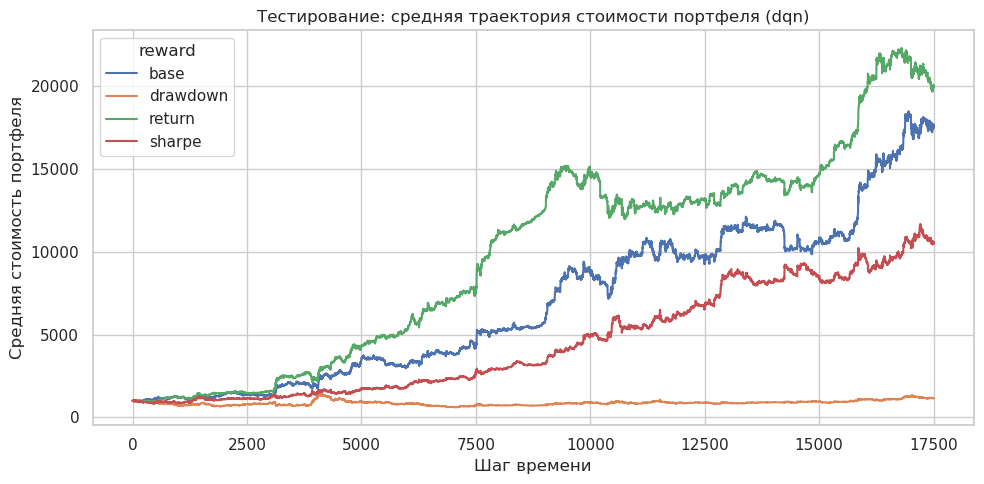

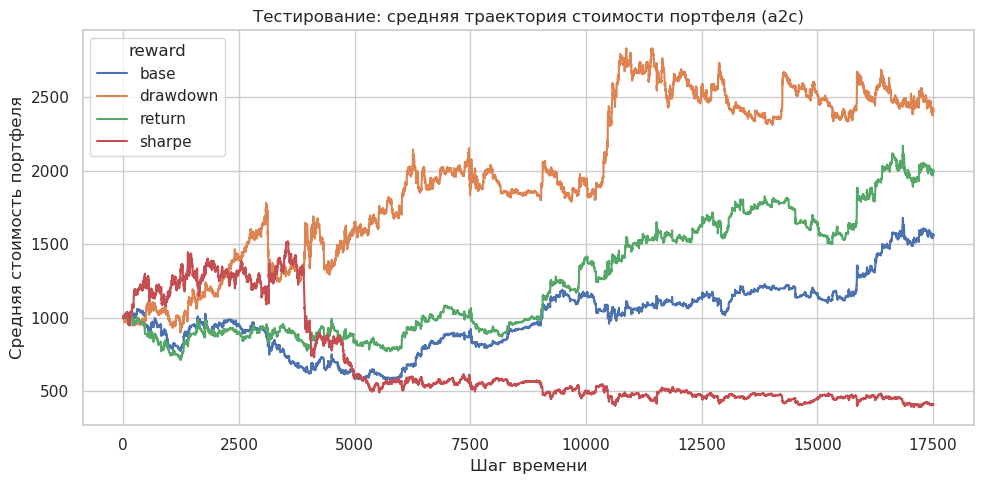

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

test_df = pd.concat(test_steps_all, ignore_index=True)

avg_df = (
    test_df.groupby(['algo', 'reward', 'step'], as_index=False)
    .agg(portfolio_value_mean=('portfolio_value', 'mean'))
)

for algo in ['dqn', 'a2c']:
    data = avg_df[avg_df['algo'] == algo]
    if data.empty:
        print(f"Нет данных для {algo}")
        continue
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data, x='step', y='portfolio_value_mean', hue='reward')
    plt.title(f"Тестирование: средняя траектория стоимости портфеля ({algo})")
    plt.xlabel("Шаг времени")
    plt.ylabel("Средняя стоимость портфеля")
    plt.tight_layout()
    plt.show()

In [52]:
test_df = pd.concat(test_steps_all, ignore_index=True)
trades_df = pd.concat(test_trades_all, ignore_index=True) if test_trades_all else pd.DataFrame()

# базовые метрики по шагам
step_groups = test_df.groupby(['algo', 'reward', 'rep'])

# экспозиции
pos = test_df[['algo', 'reward', 'rep', 'position']].copy()

def _max_drawdown(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return 0.0
    cummax = values.cummax()
    dd = values / cummax - 1.0
    return float(dd.min())

def _risk_metrics(steps):
    if len(steps) == 0:
        return {
            'max_drawdown': 0.0,
            'volatility': 0.0,
            'downside_deviation': 0.0,
            'sharpe': 0.0,
            'sortino': 0.0,
            'calmar': 0.0,
        }
    pv = steps['portfolio_value'].astype(float)
    rets = pv.pct_change().fillna(0.0)
    max_dd = _max_drawdown(pv)
    vol = float(rets.std(ddof=0))
    downside = rets[rets < 0]
    downside_dev = float(downside.std(ddof=0)) if len(downside) > 0 else 0.0
    sharpe = float(rets.mean() / vol) if vol > 0 else 0.0
    sortino = float(rets.mean() / downside_dev) if downside_dev > 0 else 0.0
    total_return = float(pv.iloc[-1] / pv.iloc[0] - 1.0)
    calmar = float(total_return / abs(max_dd)) if max_dd < 0 else 0.0
    return {
        'max_drawdown': max_dd,
        'volatility': vol,
        'downside_deviation': downside_dev,
        'sharpe': sharpe,
        'sortino': sortino,
        'calmar': calmar,
    }

metrics_rows = []
for (algo, reward, rep), steps in step_groups:
    steps = steps.reset_index(drop=True)
    pos_arr = steps['position'].fillna(0).to_numpy()

    entries_long = int(((pos_arr[1:] == 1) & (pos_arr[:-1] == 0)).sum()) if len(pos_arr) > 1 else 0
    entries_short = int(((pos_arr[1:] == -1) & (pos_arr[:-1] == 0)).sum()) if len(pos_arr) > 1 else 0

    long_exposure = float((pos_arr == 1).mean()) if len(pos_arr) > 0 else 0.0
    short_exposure = float((pos_arr == -1).mean()) if len(pos_arr) > 0 else 0.0
    flat_exposure = float((pos_arr == 0).mean()) if len(pos_arr) > 0 else 0.0

    # трейды
    if not trades_df.empty:
        t = trades_df[(trades_df['algo'] == algo) & (trades_df['reward'] == reward) & (trades_df['rep'] == rep)]
    else:
        t = pd.DataFrame()

    if len(t) > 0:
        avg_pnl = float(t['pnl'].mean())
        median_pnl = float(t['pnl'].median())
        win_rate = float((t['pnl'] > 0).mean())
        avg_hold = float(t['holding_time'].mean())
        n_trades = int(len(t))
    else:
        avg_pnl = median_pnl = win_rate = avg_hold = 0.0
        n_trades = 0

    # доходности
    if len(steps) > 0:
        total_return = float(steps['portfolio_value'].iloc[-1] / steps['portfolio_value'].iloc[0] - 1.0)
        asset_return = float(
            df_test.loc[steps['df_index'].iloc[-1], 'close']
            / df_test.loc[steps['df_index'].iloc[0], 'close']
            - 1.0
        )
        n_steps = int(len(steps))
        risk = _risk_metrics(steps)
    else:
        total_return = asset_return = 0.0
        n_steps = 0
        risk = _risk_metrics(steps)

    metrics_rows.append({
        'algo': algo,
        'reward': reward,
        'rep': rep,
        'n_steps': n_steps,
        'n_trades': n_trades,
        'avg_pnl_per_trade': avg_pnl,
        'median_pnl_per_trade': median_pnl,
        'win_rate': win_rate,
        'avg_holding_time': avg_hold,
        'entries_long': entries_long,
        'entries_short': entries_short,
        'long_exposure': long_exposure,
        'short_exposure': short_exposure,
        'flat_exposure': flat_exposure,
        'total_return': total_return,
        'asset_return': asset_return,
        'max_drawdown': risk['max_drawdown'],
        'volatility': risk['volatility'],
        'downside_deviation': risk['downside_deviation'],
        'sharpe': risk['sharpe'],
        'sortino': risk['sortino'],
        'calmar': risk['calmar'],
    })

metrics_df = pd.DataFrame(metrics_rows)

# усредняем по прогонам
metrics_summary = (
    metrics_df.groupby(['algo', 'reward'])
    .agg(
        n_steps=('n_steps', 'mean'),
        n_trades=('n_trades', 'mean'),
        avg_pnl_per_trade=('avg_pnl_per_trade', 'mean'),
        median_pnl_per_trade=('median_pnl_per_trade', 'mean'),
        win_rate=('win_rate', 'mean'),
        avg_holding_time=('avg_holding_time', 'mean'),
        entries_long=('entries_long', 'mean'),
        entries_short=('entries_short', 'mean'),
        long_exposure=('long_exposure', 'mean'),
        short_exposure=('short_exposure', 'mean'),
        flat_exposure=('flat_exposure', 'mean'),
        total_return=('total_return', 'mean'),
        asset_return=('asset_return', 'mean'),
        max_drawdown=('max_drawdown', 'mean'),
        volatility=('volatility', 'mean'),
        downside_deviation=('downside_deviation', 'mean'),
        sharpe=('sharpe', 'mean'),
        sortino=('sortino', 'mean'),
        calmar=('calmar', 'mean'),
    )
    .reset_index()
)

metrics_summary = metrics_summary.sort_values(['algo', 'total_return'], ascending=[True, False])

metrics_table = metrics_summary[[
    'algo',
    'reward',
    'total_return',
    'max_drawdown',
    'win_rate',
    'avg_holding_time',
]].rename(columns={
    'algo': 'Алгоритм',
    'reward': 'Функция награды',
    'total_return': 'Total Return',
    'max_drawdown': 'Max Drawdown',
    'win_rate': 'Win Rate',
    'avg_holding_time': 'Avg Holding Time',
})

metrics_table

,algo,reward,n_steps,n_trades,avg_pnl_per_trade,median_pnl_per_trade,win_rate,avg_holding_time,entries_long,entries_short,...,short_exposure,flat_exposure,total_return,asset_return,max_drawdown,volatility,downside_deviation,sharpe,sortino,calmar
1,a2c,drawdown,17509.0,0.0,0.0,0.0,0.0,0.0,499.0,1131.0,...,0.421212,0.236907,1.401015,-0.097875,-0.301429,0.004822,0.004061,0.012782,0.015176,4.647910
2,a2c,return,17509.0,0.0,0.0,0.0,0.0,0.0,885.0,415.0,...,0.092238,0.434462,0.986034,-0.097875,-0.305058,0.004198,0.004315,0.011434,0.011125,3.232280
0,a2c,base,17509.0,0.0,0.0,0.0,0.0,0.0,841.0,450.0,...,0.116854,0.452053,0.554454,-0.097875,-0.457649,0.004188,0.004421,0.008111,0.007683,1.211527
3,a2c,sharpe,17509.0,0.0,0.0,0.0,0.0,0.0,359.0,323.0,...,0.492604,0.044377,-0.587270,-0.097875,-0.741853,0.005800,0.005346,-0.005805,-0.006298,-0.791626
6,dqn,return,17509.0,0.0,0.0,0.0,0.0,0.0,4331.0,261.0,...,0.040037,0.410589,18.946002,-0.097875,-0.220504,0.004498,0.004581,0.040253,0.039523,85.921434
4,dqn,base,17509.0,0.0,0.0,0.0,0.0,0.0,644.0,64.0,...,0.029471,0.044491,16.499764,-0.097875,-0.238549,0.005507,0.004360,0.032436,0.040967,69.167330
7,dqn,sharpe,17509.0,0.0,0.0,0.0,0.0,0.0,1297.0,467.0,...,0.419441,0.169284,9.500247,-0.097875,-0.202370,0.005303,0.004322,0.027972,0.034322,46.944941
5,dqn,drawdown,17509.0,0.0,0.0,0.0,0.0,0.0,23.0,4.0,...,0.377520,0.002227,0.157163,-0.097875,-0.570677,0.005673,0.004308,0.004305,0.005669,0.275397
